# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Seed
seed = 42

# Data

In [2]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml(
    'titanic',
    version=1,
    return_X_y=True,
    as_frame=True,
)

df = X.copy()
df['survived'] = y

# 1. Feature Distribution

## 1) Percentiles

In [3]:
df.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

,pclass,age,sibsp,parch,fare,body
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,256.000000
95%,3.000000,57.000000,2.000000,2.000000,133.650000,307.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


## 2) Frequency

In [4]:
df.describe(exclude='number')   # for categorical/string columns.

,name,sex,ticket,cabin,embarked,boat,home.dest,survived
count,1309,1309,1309,295,1307,486,745,1309
unique,1307,2,929,186,3,27,369,2
top,"Connolly, Miss. Kate",male,CA. 2343,C23 C25 C27,S,13,"New York, NY",0
freq,2,843,11,6,914,39,64,809


## 3) Histogram

### basic

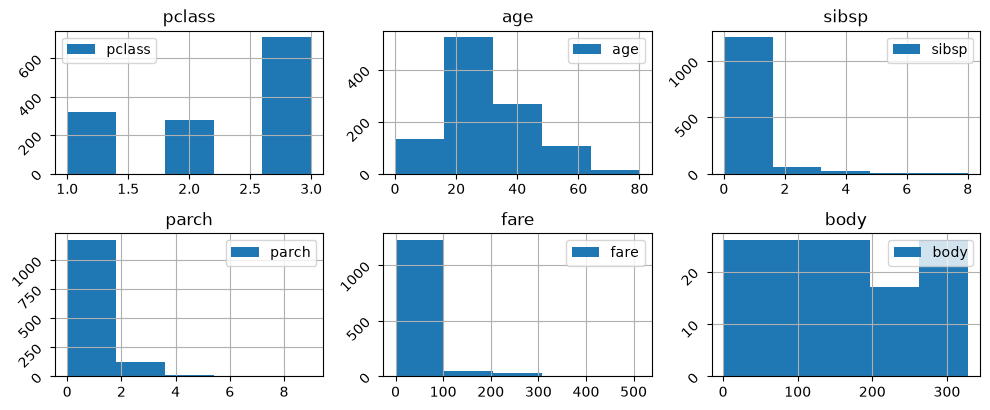

In [5]:
df.hist(
    bins=5,             # how many bins for each feature.         
    grid=True,          # background grid line.
    xlabelsize=10,      # x-label size.
    ylabelsize=10,      # y-label size.
    xrot=0,             # x-label rotation.
    yrot=45,            # y-label rotation.
    sharex=False,       # share x-axis.
    sharey=False,       # share y-axis.
    legend=True,        # legend for each histogram.
    figsize=(10, 6),    # (width, height).
    layout=(3, 3),      # (n_rows, n_cols).
)

plt.tight_layout()

### by group

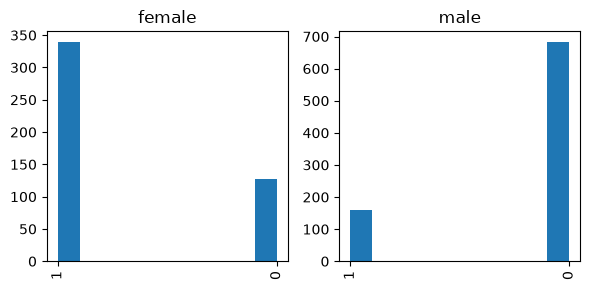

In [6]:
df.hist(
    column='survived',
    by='sex',
    figsize=(6, 3),
)

plt.tight_layout()

## 4) Skewness

- Definition
  - How much is the distribution **symmetric**?
  - $skew \approx E[(\frac{X - \mu}{\sigma})^3]$
- Range
  - $skew \approx 0$: roughly symmetric
  - $abs(skew) \gg 0$: strong asymmetric
  - $skew \gt 0$: positive/right skewed; long right tail
  - $skew \lt 0$: negative/left skewed; long left tail
> Note) When the `abs(skewness)` is too large, consider using `median` instead `mean`.

In [7]:
df_ = pd.DataFrame({
    "symmetric":  [1, 2, 3, 4, 5, 6, 7],
    "right_skew": [1, 2, 2, 3, 3, 4, 15],
    "left_skew":  [-15, -4, -3, -3, -2, -2, -1],
})

df_.skew()

symmetric     0.000000
right_skew    2.429384
left_skew    -2.429384
dtype: float64

## 5) Kurtosis

- Definition
  - How strongly does the distribution produce **extreme observations** relative to its overall spread?
  - $kurtosis_{pearson} \approx E[(\frac{X - \mu}{\sigma})^4]$
  - $kurtosis_{excess} = kurtosis_{pearson} - 3$
    - because $kurtosis_{pearson}$ for a normal distribution is 3.
    - `pandas` uses $kurtosis_{excess}$.

In [8]:
x = pd.Series([-10, -1, 0, 0, 0, 1, 10])

print(f"Skew: {x.skew():.4f}")              # 0.0
print(f"Kurtosis: {x.kurtosis():.4f}")      # ≈ 2.835

Skew: 0.0000
Kurtosis: 2.8353


## 6) KDE and CDF

- KDE: Kernel Density Estimation
  - A smooth version of histogram.
- ECDF: Emperical Culmulative Distribution Function
  - A number of observations that are less than $x$.
  - $F(x) = P(X \leq x) = \frac{len(x_i \leq x)}{n}$

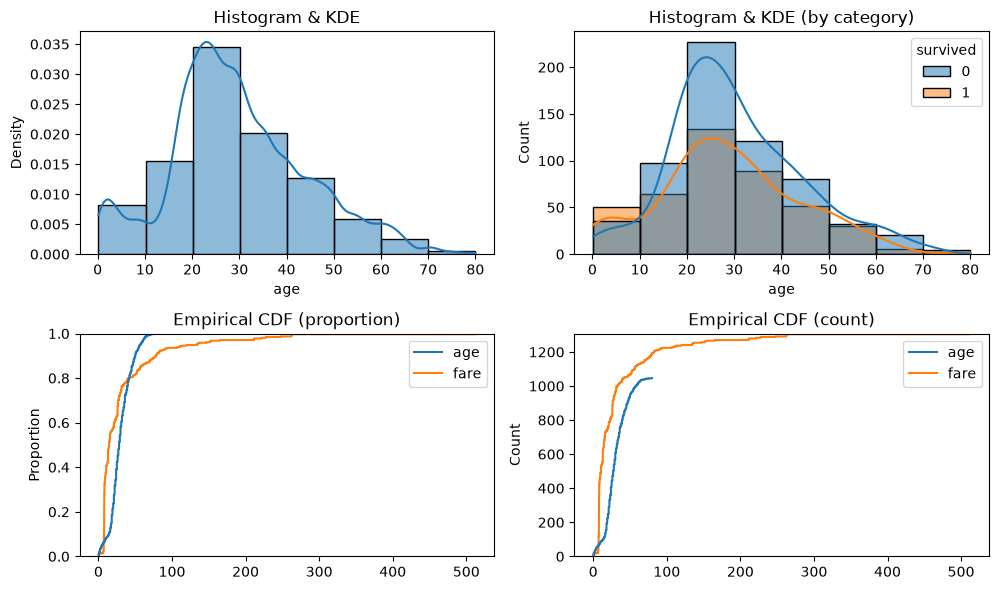

In [9]:
df_ = df[['age', 'fare', 'sex', 'survived']]
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Histogram & KDE
sns.histplot(
    data=df_['age'],        # df.
    binwidth=10,            # bin size on the histogram.
    stat='density',         # y-axis. {'density', 'count'}.

    kde=True,               # plot kde.
    kde_kws={               # kde keywords.
        'bw_adjust': 0.5,   # kde bandwidth, i.e. greater -> smoother.
    },

    ax=axes[0][0],          # ax to plot.
)
axes[0][0].set_title("Histogram & KDE")

# KDE by category
sns.histplot(
    data=df_[['age', 'survived']],
    binwidth=10,
    x='age',
    kde=True,
    hue='survived',
    ax=axes[0][1],
)
axes[0][1].set_title("Histogram & KDE (by category)")

# Empirical CDF
sns.ecdfplot(
    data=df_[['age', 'fare']],
    ax=axes[1][0],
    stat='proportion',      # y-axis. {'proportion', 'percent', 'count'}.
)
axes[1][0].set_title("Empirical CDF (proportion)")

sns.ecdfplot(
    data=df_[['age', 'fare']],
    ax=axes[1][1],
    stat='count',
)
axes[1][1].set_title("Empirical CDF (count)")


plt.tight_layout()
plt.show()

## 7) Normality

### Q-Q Plot

- Quantile-Quantile plot.
- How much is the distribution similar to the normal distribution?
- More similar to the diagonal line -> more likely normal distribution.
> Note) NaN should be removed before Q-Q plot.

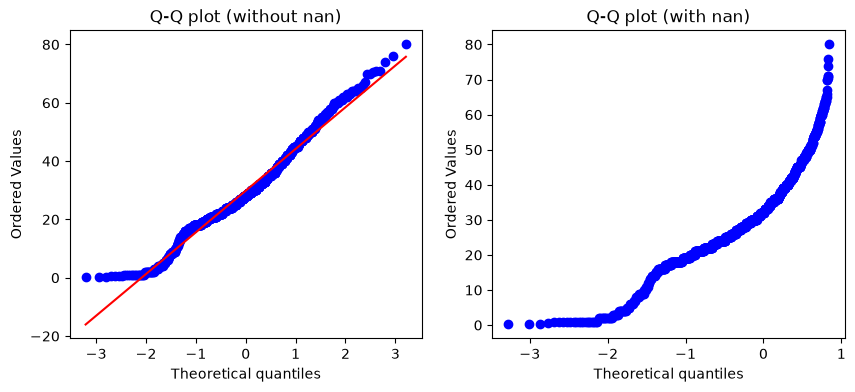

In [10]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_ = df['age'].dropna()

stats.probplot(
    df_,
    dist="norm",
    plot=axes[0],
)
axes[0].set_title("Q-Q plot (without nan)")

stats.probplot(
    df['age'],
    dist="norm",
    plot=axes[1],
)
axes[1].set_title("Q-Q plot (with nan)")

plt.show()

### Shapiro-Wilk Test

- $W \approx 1$ -> more likely normal distribution.
- $p \geq 0.05$ -> more likely normal distibution.

In [11]:
stat, p = stats.shapiro(x)

print(f"W = {stat:.3f}, p = {p:.3f}")

W = 0.845, p = 0.112


# 2. Correlation Analysis

- **Covariance**
  - How two variables vary together.
  - $\mathrm{Cov}(X,Y) = \sum (x_i-\bar{x})(y_i-\bar{y}) \;/\; (n-1)$

- **Pearson**
  - A strength of a linear relationship.
  - $r = \frac{\sum\_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum\_{i=1}^{n}(x_i-\bar{x})^2\sum\_{i=1}^{n}(y_i-\bar{y})^2}} = \frac{Cov(X, Y)}{\sqrt{var(x) \times var(y)}}$

- **Spearman**
  - A strength of a monotonic relationship using ranks.
  - $\rho = 1-\frac{6\sum\_{i=1}^{n}d_i^2}{n(n^2-1)}$
  - $d_i = Rank(x_i) - Rank(y_i)$

- **Kendall**
  - A rank association by comparing pairs.
  - $\tau = \frac{C-D}{\binom{n}{2}} = \frac{C-D}{n(n-1)/2}$
  - $C$ = number of concordant pairs = $X \uparrow\ \rightarrow Y \uparrow$
  - $D$ = number of discordant pairs = $X \uparrow\ \rightarrow Y \downarrow$

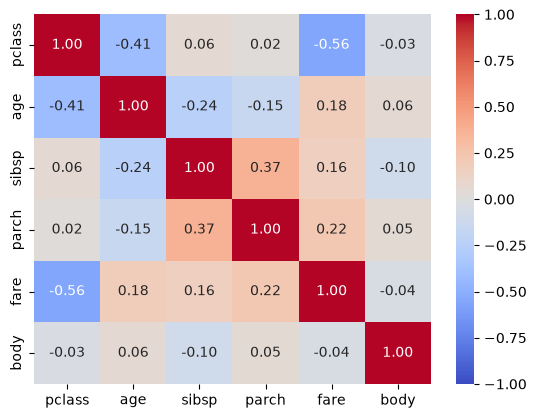

In [12]:
corr = df.corr(
    numeric_only=True,
    method='pearson',       # {'pearson', 'kendall', 'spearman'} or callable.
)

sns.heatmap(
    corr,
    annot=True,       # show correlation values.
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
)

plt.show()

# 3. Feature Importance

## 1) Random Forest

- Accumulates the decrease of impurity for each feature/split.
- e.g. '0.65' -> this feature contributes about 65% of the total decrease of impurity.

In [13]:
from sklearn.ensemble import RandomForestClassifier

X, y = load_iris(return_X_y=True, as_frame=True)

model = RandomForestClassifier(random_state=seed)
model.fit(X=X, y=y)

model.feature_importances_

array([0.10612762, 0.02167809, 0.43612951, 0.43606478])

## 2) Permutation

- Randomize each feature -> observes how much the performance decreases.

In [14]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X=X,
    y=y,
    n_repeats=20,
    random_state=seed,
    scoring="accuracy",
)

importance = pd.Series(
    result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print(importance)

petal length (cm)    0.216333
petal width (cm)     0.180667
sepal length (cm)    0.014667
sepal width (cm)     0.012000
dtype: float64


## 3) Mutual Information

- $MI(X;Y)=H(Y)−H(Y∣X)$
  - How much the uncertainty of $Y$ decreases before/after knowing $X$.
  - $H(Y)=−y ∑ [​p(y) \times log (p(y))]$

In [15]:
from sklearn.feature_selection import mutual_info_classif

scores = mutual_info_classif(
    X, y,
    random_state=seed,
)

importance = pd.Series(
    scores,
    index=X.columns
).sort_values(ascending=False)

print(importance)

petal length (cm)    0.992573
petal width (cm)     0.985643
sepal length (cm)    0.511365
sepal width (cm)     0.299424
dtype: float64
